# Proyecto 2 — Análisis exploratorio de datos
## Tema 22: Clasificación de los orígenes de un coágulo de sangre en un accidente cerebrovascular

**Universidad del Valle de Guatemala · CC3084 Data Science · Semestre II de 2026**

**Integrante:** Jorge Luis Lopez 221038  

**Antes de interpretar resultados:** hay 754 registros de metadatos, pero solo seis imágenes derivadas disponibles. Tres corresponden a etiquetas del CSV; las otras tres se mantienen sin etiqueta. No se ha entrenado un clasificador.

## 1. Situación problemática

El accidente cerebrovascular (ACV) isquémico ocurre cuando se interrumpe la irrigación de una región del cerebro, frecuentemente por una obstrucción arterial. Un coágulo puede formarse en un vaso enfermo o desplazarse desde otro lugar. Identificar su origen motiva el reto de clasificación CE/LAA. [NINDS: Stroke Overview](https://www.ninds.nih.gov/health-information/stroke/stroke-overview).

El reto STRIP AI estudia imágenes histopatológicas de coágulos de pacientes que ya presentaron un ACV isquémico. Su objetivo es distinguir etiología cardioembólica (CE) de ateroesclerosis de grandes arterias (LAA). Por tanto, la tarea consiste en investigar el **origen del coágulo**, no en detectar si una persona sana tendrá un ACV. [Kaggle: descripción de los datos](https://www.kaggle.com/competitions/mayo-clinic-strip-ai/data).

Para explorar estos datos primero deben conocerse el balance de etiquetas, la repetición de pacientes, la distribución por centro y la calidad de las imágenes. Una diferencia de color o nitidez puede depender de cómo se preparó la imagen; no basta para afirmar una diferencia biológica entre etiologías.

## 2. Problema científico

**¿Qué patrones de distribución, relaciones entre variables y problemas de calidad presentan los metadatos y las imágenes disponibles del reto CE/LAA, y qué limitaciones deben resolverse antes de estudiar una clasificación por origen del coágulo?**

Preguntas exploratorias:

1. ¿Cambian las proporciones CE/LAA al contar imágenes o pacientes?
2. ¿Cómo varía la composición de clases entre centros y cuántas imágenes aporta cada paciente?
3. ¿Qué archivos de imagen tienen correspondencia verificable con las etiquetas?
4. ¿Cómo varían cobertura aproximada de tejido, nitidez, color y entropía dentro de las imágenes?
5. ¿Cómo cambian los recortes aceptados al modificar el umbral de tejido?

Estas preguntas son descriptivas y alcanzables con los archivos presentes. La capacidad de predecir CE/LAA queda fuera de esta fase.

## 3. Objetivos

**General:** caracterizar los metadatos y las imágenes locales mediante un EDA reproducible que documente distribuciones, relaciones, calidad y limitaciones para el problema CE/LAA.

**Específicos:**

1. Auditar el 100 % de las filas del CSV: esquema, faltantes, duplicados, identificadores y consistencia por paciente.
2. Cuantificar frecuencias y proporciones de clases por imagen y paciente, y cruzarlas con centro y número de imágenes por paciente.
3. Inventariar los seis archivos de imagen y calcular medidas descriptivas de cobertura, color, nitidez y entropía sobre cada imagen y sus tiles.
4. Exportar gráficos y tablas de distribuciones, atípicos, relaciones y sensibilidad a tres umbrales de cobertura.
5. Redactar conclusiones limitadas por los resultados observados y proponer siguientes pasos verificables.

## 4. Investigación preliminar

### Enfermedad y síntomas

El ACV isquémico implica interrupción del flujo sanguíneo cerebral. Entre sus mecanismos se encuentran trombosis, embolia y estrechamiento arterial por ateroesclerosis. Un émbolo puede viajar desde el corazón u otra arteria hasta un vaso cerebral. [NINDS: Stroke Overview](https://www.ninds.nih.gov/health-information/stroke/stroke-overview).

Los síntomas suelen comenzar de forma súbita: debilidad o adormecimiento de un lado del cuerpo, dificultad para hablar o comprender, alteraciones visuales y pérdida de equilibrio o coordinación. Estos síntomas motivan la evaluación clínica, pero no son variables disponibles en nuestro CSV. [NINDS: Signs and Symptoms](https://www.ninds.nih.gov/health-information/stroke/signs-and-symptoms).

### Diagnóstico, especialmente por imágenes

La valoración clínica incluye una exploración neurológica. La tomografía computarizada (TC) de cráneo permite buscar hemorragia; la angiografía por TC ayuda a evaluar vasos y obstrucciones. La resonancia magnética (RM), especialmente con difusión, puede detectar lesiones isquémicas tempranas y pequeñas. Se combinan estas imágenes con otros estudios según la evaluación médica. [NINDS: Assess and Treat](https://www.ninds.nih.gov/health-information/stroke/assess-and-treat).

### Qué patrón se busca aquí

Las imágenes del reto son de **tejido del coágulo**, una modalidad diferente de TC o RM cerebral. La hipótesis de trabajo del área es que la composición y organización del trombo pueden aportar información sobre su origen. Un estudio del registro STRIP con 105 pacientes analizó proporciones de eritrocitos, fibrina, plaquetas y leucocitos; encontró asociaciones entre trombos ricos en plaquetas y etiología LAA en su cohorte. Empleó tinciones y mediciones histológicas específicas. [Fitzgerald et al., 2019](https://pmc.ncbi.nlm.nih.gov/articles/PMC6910081/).

**Implicación para nuestro EDA:** explorar variación espacial, color y textura, junto con calidad de adquisición. Las estadísticas RGB y la entropía aquí calculadas no identifican por sí mismas componentes celulares. No conocemos con certeza la tinción ni la escala física de todos los derivados locales; por ello no se aplica deconvolución H&E ni se asignan diagnósticos visuales.

## 5. Datos, procedencia y unidades de observación

El CSV contiene cinco campos, cuya semántica se contrasta con la [documentación oficial del reto](https://www.kaggle.com/competitions/mayo-clinic-strip-ai/data).

| Variable | Tipo semántico | Uso en el EDA |
|---|---|---|
| `image_id` | Identificador nominal (texto) | Identificación única de imagen |
| `patient_id` | Identificador nominal (texto) | Agrupación de imágenes del mismo paciente |
| `center_id` | Categórica nominal, almacenada como entero | Centro de obtención; frecuencias y cruces |
| `image_num` | Índice entero de imagen dentro de paciente | Consistencia del identificador; no es cantidad de imágenes |
| `label` | Categórica nominal binaria | Etiología CE/LAA |

El número de imágenes por paciente, `n_imagenes`, se deriva contando registros. Se distinguen tres unidades: **paciente**, **imagen** y **tile** (región de una imagen). Un tile no es un paciente adicional.

Los PNG proceden de `P2-DS/fase1/data`; los JPG, de `P2-DS/fase3/images`. Se copió también `train.csv`. No se copiaron el código de entrenamiento ni los resultados estadísticos del ejemplo. Las rutas y huellas SHA-256 permiten auditar estas copias. Los archivos derivados no equivalen a las láminas originales completas.

## 6. Configuración y ejecución reproducible

La siguiente celda ejecuta el análisis completo y actualiza `resultados/`. No escribe en `P2-DS`. `analisis.py` contiene las funciones de carga, validación, medición, filtrado y exportación. La cuadrícula no utiliza aleatoriedad; repetirla con los mismos archivos y parámetros produce los mismos recortes.

Las dependencias se instalan desde `requirements.txt` antes de abrir el notebook. La raíz del proyecto debe contener `analisis.py`, `datos/` y este notebook.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image as Imagen
import pandas as pd

candidatas = [Path.cwd(), Path.cwd().parent]
RAIZ = next((p for p in candidatas if (p / "analisis.py").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Abrir el notebook desde la raíz de P2-DataScience.")
sys.path.insert(0, str(RAIZ))
from analisis import ejecutar, METRICAS, PARAMETROS

resultado = ejecutar(RAIZ)
metadatos = resultado["metadatos"]
pacientes = resultado["pacientes"]
imagenes = resultado["imagenes"]
tiles = resultado["tiles"]
aceptados = resultado["tiles_aceptados"]

def tabla(nombre, **kwargs):
    return pd.read_csv(RAIZ / "resultados/tablas" / f"{nombre}.csv", **kwargs)

def figura(nombre, ancho=1000):
    display(Imagen(filename=str(RAIZ / "resultados/figuras" / f"{nombre}.png"), width=ancho))

display(pd.Series(resultado["resumen"], name="valor").to_frame())
display(pd.Series(PARAMETROS, name="parámetro").to_frame())

,valor
observaciones,754
variables_originales,5
pacientes,632
centros,11
clases_imagenes,"{'CE': 547, 'LAA': 207}"
clases_pacientes,"{'CE': 457, 'LAA': 175}"
nulos,0
duplicados_eliminados,0
pacientes_multiples_imagenes,89
max_imagenes_paciente,5


,parámetro
lado_tile,128.00
gris_umbral,230.00
saturacion_umbral,0.10
tejido_minimo,0.25
nitidez_minima,2.00


## 7. Descripción inicial, limpieza y faltantes

Se leen los identificadores como texto para conservar ceros iniciales. Se revisan espacios externos, etiquetas en mayúsculas, vacíos, duplicados exactos y valores enteros válidos. Se comprueba que `image_id` coincida con `patient_id + '_' + image_num` y que cada paciente tenga una etiqueta y un centro consistentes.

**Decisiones:** eliminar solo duplicados exactos si existen; detener el análisis ante conflictos de identificadores, etiquetas faltantes o inválidas. No imputar identificadores, centros o etiologías. Conservar las múltiples imágenes válidas de un paciente. `metadatos_limpios.csv` es una salida separada del original.

In [2]:
display(metadatos.head(10))
display(pd.DataFrame({"tipo_python": metadatos.dtypes.astype(str),
                      "valores_distintos": metadatos.nunique()}))
display(tabla("calidad_metadatos"))
print("Duplicados exactos eliminados:", resultado["resumen"]["duplicados_eliminados"])
print("Registros antes y después:", len(pd.read_csv(RAIZ / "datos/train.csv")), len(metadatos))

,image_id,center_id,patient_id,image_num,label
0,006388_0,11,006388,0,CE
1,008e5c_0,11,008e5c,0,CE
2,00c058_0,11,00c058,0,LAA
3,01adc5_0,11,01adc5,0,LAA
4,026c97_0,4,026c97,0,CE
5,028989_0,5,028989,0,LAA
6,029c68_0,5,029c68,0,CE
7,032f10_0,7,032f10,0,CE
8,0372b0_0,7,0372b0,0,CE
9,037300_0,11,037300,0,CE


,tipo_python,valores_distintos
image_id,string,754
center_id,int64,11
patient_id,string,632
image_num,int64,5
label,string,2


,variable,nulos_originales,nulos_normalizados,celdas_normalizadas
0,image_id,0,0,0
1,center_id,0,0,0
2,patient_id,0,0,0
3,image_num,0,0,0
4,label,0,0,0


Duplicados exactos eliminados: 0
Registros antes y después: 754 754


**Lectura:** el CSV local no tiene valores nulos ni duplicados exactos; tampoco se detectaron conflictos por paciente. Las operaciones de normalización se auditan en la tabla. No fue necesario imputar ni eliminar observaciones. Los identificadores con ceros iniciales se conservan. El hecho de que una columna se almacene como entero no convierte `center_id` en una medida clínica continua.

## 8. Variables categóricas y balance de clases

Se calculan frecuencias absolutas, proporciones y porcentajes con dos denominadores: imágenes y pacientes únicos. Cada paciente aporta una sola etiqueta después de verificar su consistencia. También se muestran las frecuencias de centro y del índice `image_num`; este último enumera las imágenes, no mide gravedad.

**Frecuencias de clases por imagen**

In [3]:
display(tabla("frecuencia_label_imagenes"))

,label,frecuencia,proporcion,porcentaje
0,CE,547,0.725464,72.546419
1,LAA,207,0.274536,27.453581


**Frecuencias de clases por paciente**

In [4]:
display(tabla("frecuencia_label_pacientes"))

,label,frecuencia,proporcion,porcentaje
0,CE,457,0.723101,72.310127
1,LAA,175,0.276899,27.689873


**Frecuencias de centros por imagen**

In [5]:
display(tabla("frecuencia_center_id_imagenes"))

,center_id,frecuencia,proporcion,porcentaje
0,1,54,0.071618,7.161804
1,2,29,0.038462,3.846154
2,3,49,0.064987,6.498674
3,4,114,0.151194,15.119363
4,5,38,0.050398,5.039788
5,6,38,0.050398,5.039788
6,7,99,0.131300,13.129973
7,8,16,0.021220,2.122016
8,9,16,0.021220,2.122016
9,10,44,0.058355,5.835544


**Frecuencias del índice de imagen**

In [6]:
display(tabla("frecuencia_image_num_imagenes"))

,image_num,frecuencia,proporcion,porcentaje
0,0,632,0.838196,83.819629
1,1,89,0.118037,11.803714
2,2,21,0.027851,2.785146
3,3,8,0.010610,1.061008
4,4,4,0.005305,0.530504


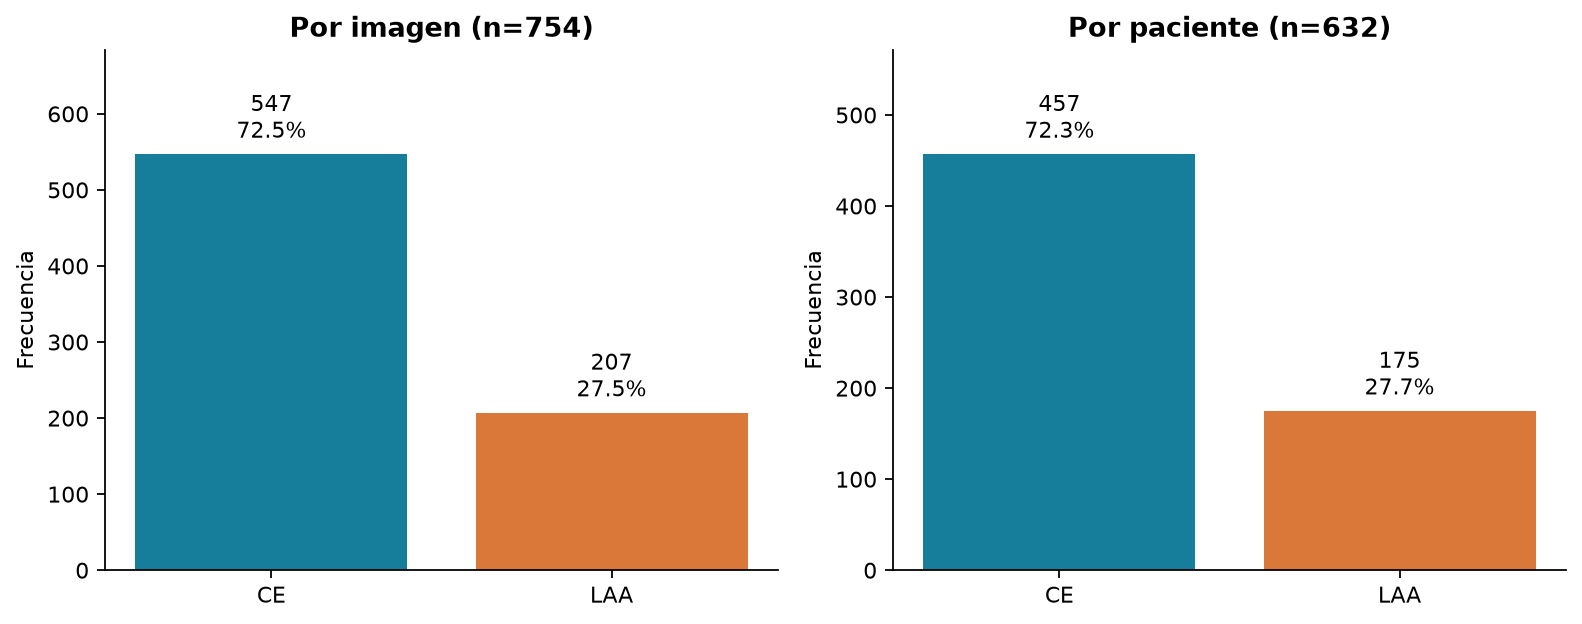

In [7]:
figura("01_balance_clases")

CE representa **72.55% de las imágenes** y **72.31% de los pacientes**. El predominio persiste al cambiar la unidad de conteo. Son proporciones del conjunto local, no estimaciones de prevalencia clínica. En una futura evaluación de clasificación, el desbalance obliga a revisar el desempeño de ambas clases y no solo exactitud global.

## 9. Cruces de variables y estadísticas por paciente

Se cruza **centro × etiqueta** usando pacientes para evitar que quienes tienen más imágenes pesen más. Se complementan porcentajes con conteos. Después se estudia **clase × número de imágenes por paciente**, una variable cuantitativa discreta derivada.

,center_id,CE,LAA
0,1,38,10
1,2,18,3
2,3,19,19
3,4,67,22
4,5,22,8
5,6,19,13
6,7,48,20
7,8,14,2
8,9,13,2
9,10,25,7


,center_id,CE,LAA
0,1,0.791667,0.208333
1,2,0.857143,0.142857
2,3,0.500000,0.500000
3,4,0.752809,0.247191
4,5,0.733333,0.266667
5,6,0.593750,0.406250
6,7,0.705882,0.294118
7,8,0.875000,0.125000
8,9,0.866667,0.133333
9,10,0.781250,0.218750


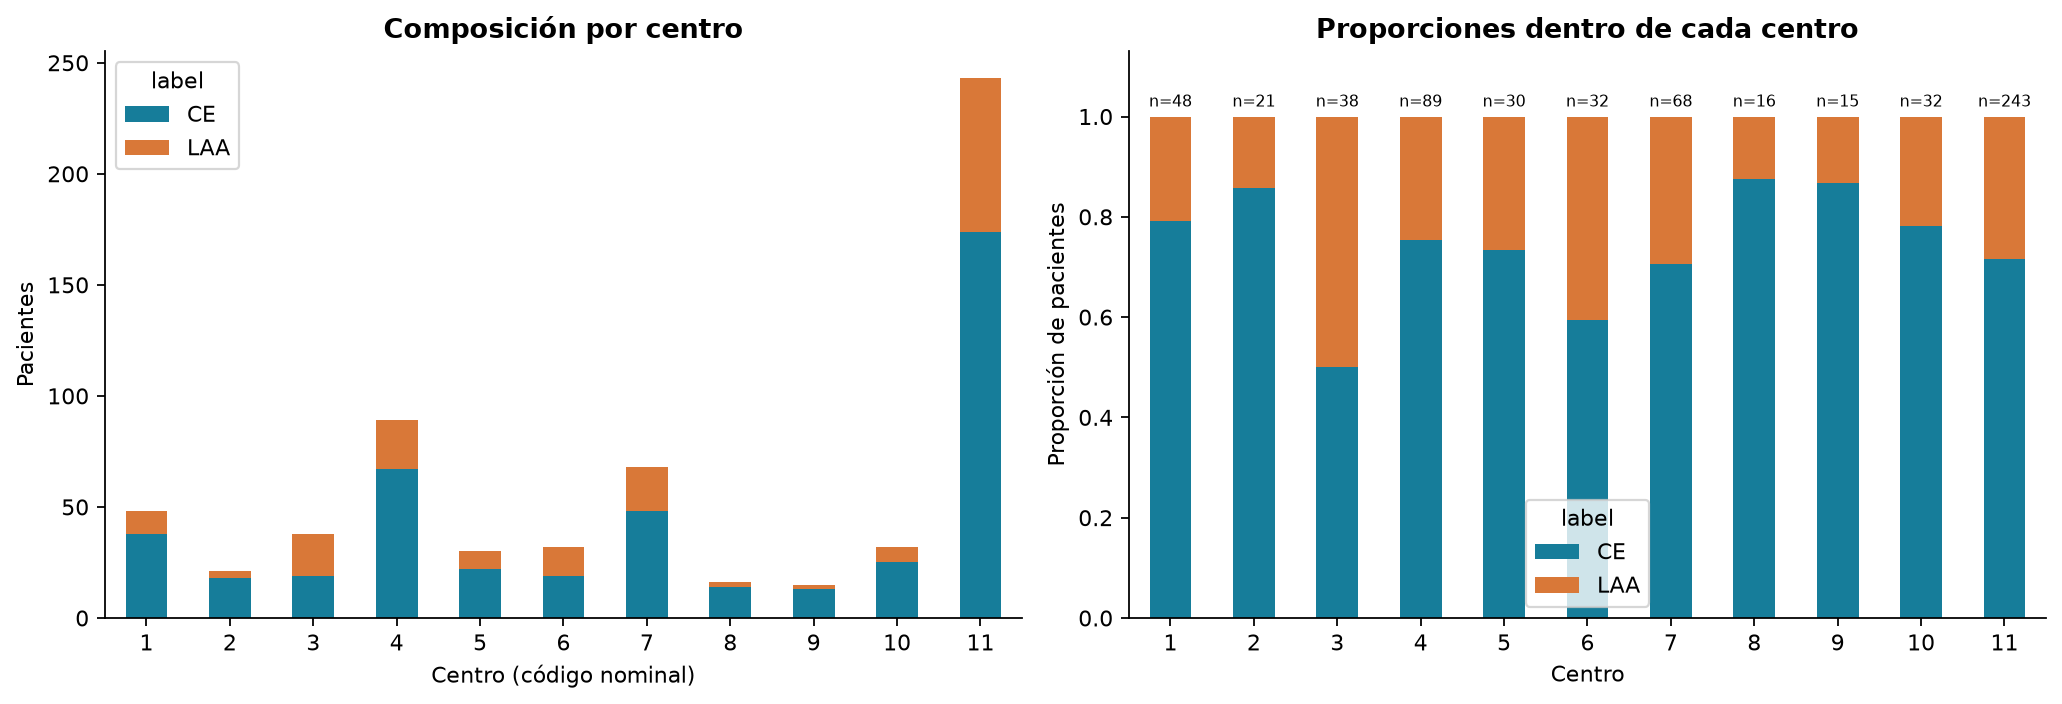

,Unnamed: 0,count,mean,std,min,25%,50%,75%,max
0,n_imagenes,632.0,1.193038,0.55797,1.0,1.0,1.0,1.0,5.0


,label,count,mean,std,min,25%,50%,75%,max
0,CE,457.0,1.196937,0.562489,1.0,1.0,1.0,1.0,5.0
1,LAA,175.0,1.182857,0.547453,1.0,1.0,1.0,1.0,5.0


,n_imagenes,CE,LAA
0,1,391,152
1,2,51,17
2,3,9,4
3,4,3,1
4,5,3,1


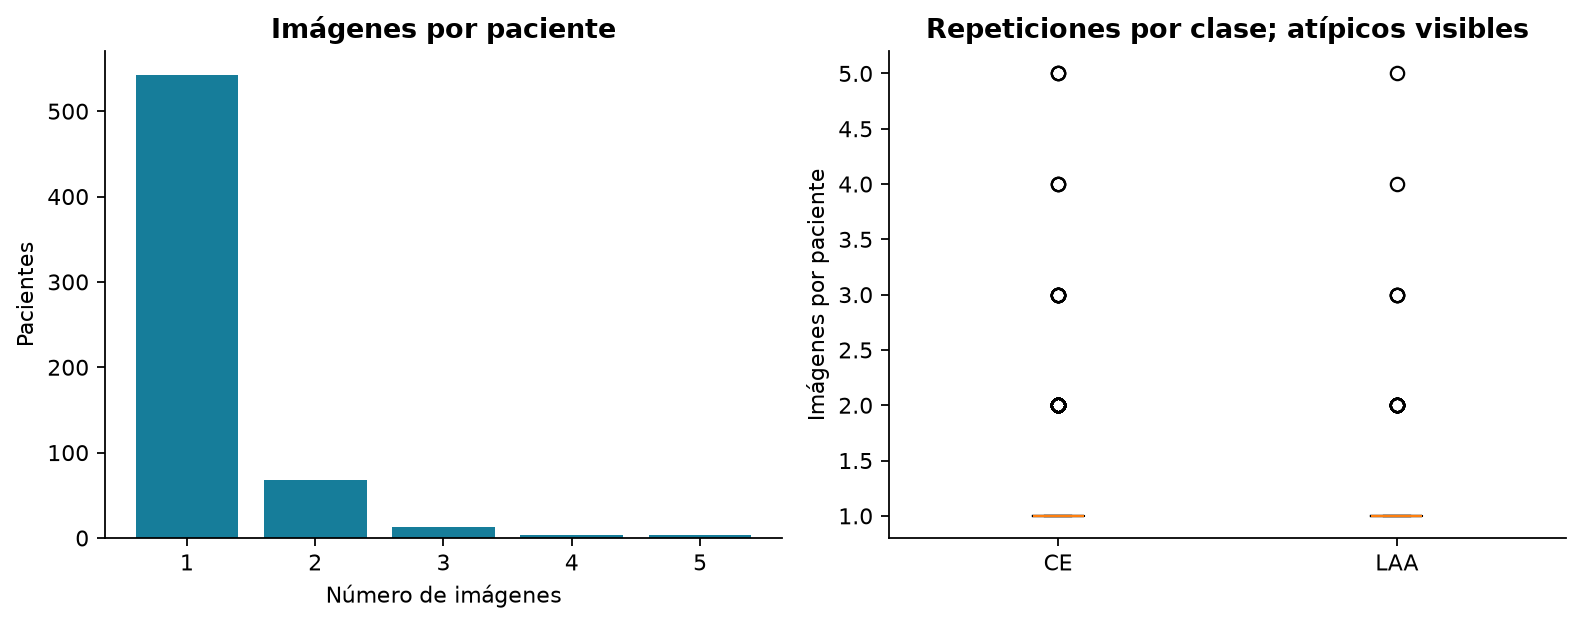

In [8]:
display(tabla("centro_clase_pacientes"))
display(tabla("centro_clase_proporciones"))
figura("02_centro_clase")
display(tabla("resumen_numerico_pacientes"))
display(tabla("imagenes_paciente_por_clase"))
display(tabla("n_imagenes_clase"))
figura("03_imagenes_por_paciente")

La proporción CE oscila entre **50.0%** y **87.5%**. El centro 11 aporta más pacientes (**243**). Estas diferencias pueden reflejar selección de casos o prácticas de los centros; no establecen causalidad. Hay **89 pacientes con varias imágenes**. Si posteriormente se entrena un modelo, todas las imágenes y tiles de un paciente deben permanecer en la misma partición.

## 10. Inventario y preprocesamiento de imágenes

Se abren los archivos locales con Pillow y se convierten a RGB. No se redimensionan ni se modifica su tinción. La correspondencia de etiquetas se hace por coincidencia exacta del identificador; para los JPG se retira únicamente el sufijo documentado `_tissue2048`.

Para una máscara aproximada se marca un píxel cuando su luminancia es menor que 230 **o** su saturación es mayor que 0.10. Se usa luminancia `0.299 R + 0.587 G + 0.114 B` y saturación `(max(R,G,B) - min(R,G,B)) / max(R,G,B)`, con cero cuando el denominador es cero. Son reglas de separación de fondo, no segmentación histológica validada.

Se construye una cuadrícula no solapada de 128 × 128 píxeles sobre cada archivo. Se omiten bordes incompletos y se registran los píxeles omitidos. Un tile se acepta si su cobertura aproximada de tejido es al menos 25 % y la varianza de su Laplaciano es al menos 2.0. Estos umbrales son operativos, no clínicos. Un rechazo no borra datos: `tiles_todos.csv` conserva coordenadas, métricas y motivos.

No se obliga a producir un tile cuando ninguno cumple los filtros. Para un tile sin tejido, las medias RGB de tejido quedan faltantes de forma intencional; no se sustituyen por cero. Las máscaras se muestran a continuación para inspección visual.

,image_id,preparacion,label,estado_etiqueta,center_id,ancho_px,alto_px,tamano_mb,tejido_fraccion,tiles_candidatos,tiles_aceptados,pixeles_borde_omitidos
0,02ebd5_0,vista_png,<NA>,sin_correspondencia_en_csv,<NA>,1414,1316,1.717584,0.215379,110,36,58584
1,0412ab_0,vista_png,<NA>,sin_correspondencia_en_csv,<NA>,1492,1302,1.977406,0.187639,110,31,140344
2,08b8ef_0,vista_png,<NA>,sin_correspondencia_en_csv,<NA>,684,1306,0.593745,0.146677,50,15,74104
3,006388_0,recorte_jpg,CE,coincide_con_csv,11,2048,2048,1.817284,0.909489,256,247,0
4,008e5c_0,recorte_jpg,CE,coincide_con_csv,11,2048,2048,2.312214,0.714768,256,221,0
5,00c058_0,recorte_jpg,LAA,coincide_con_csv,11,2048,2048,2.309044,0.997304,256,256,0


,image_id,aceptado,poco_tejido
0,006388_0,247,9
1,008e5c_0,221,35
2,00c058_0,256,0
3,02ebd5_0,36,74
4,0412ab_0,31,79
5,08b8ef_0,15,35


Faltantes en el inventario (origen: falta de correspondencia en el CSV):


,nulos
label,3
patient_id,3
center_id,3


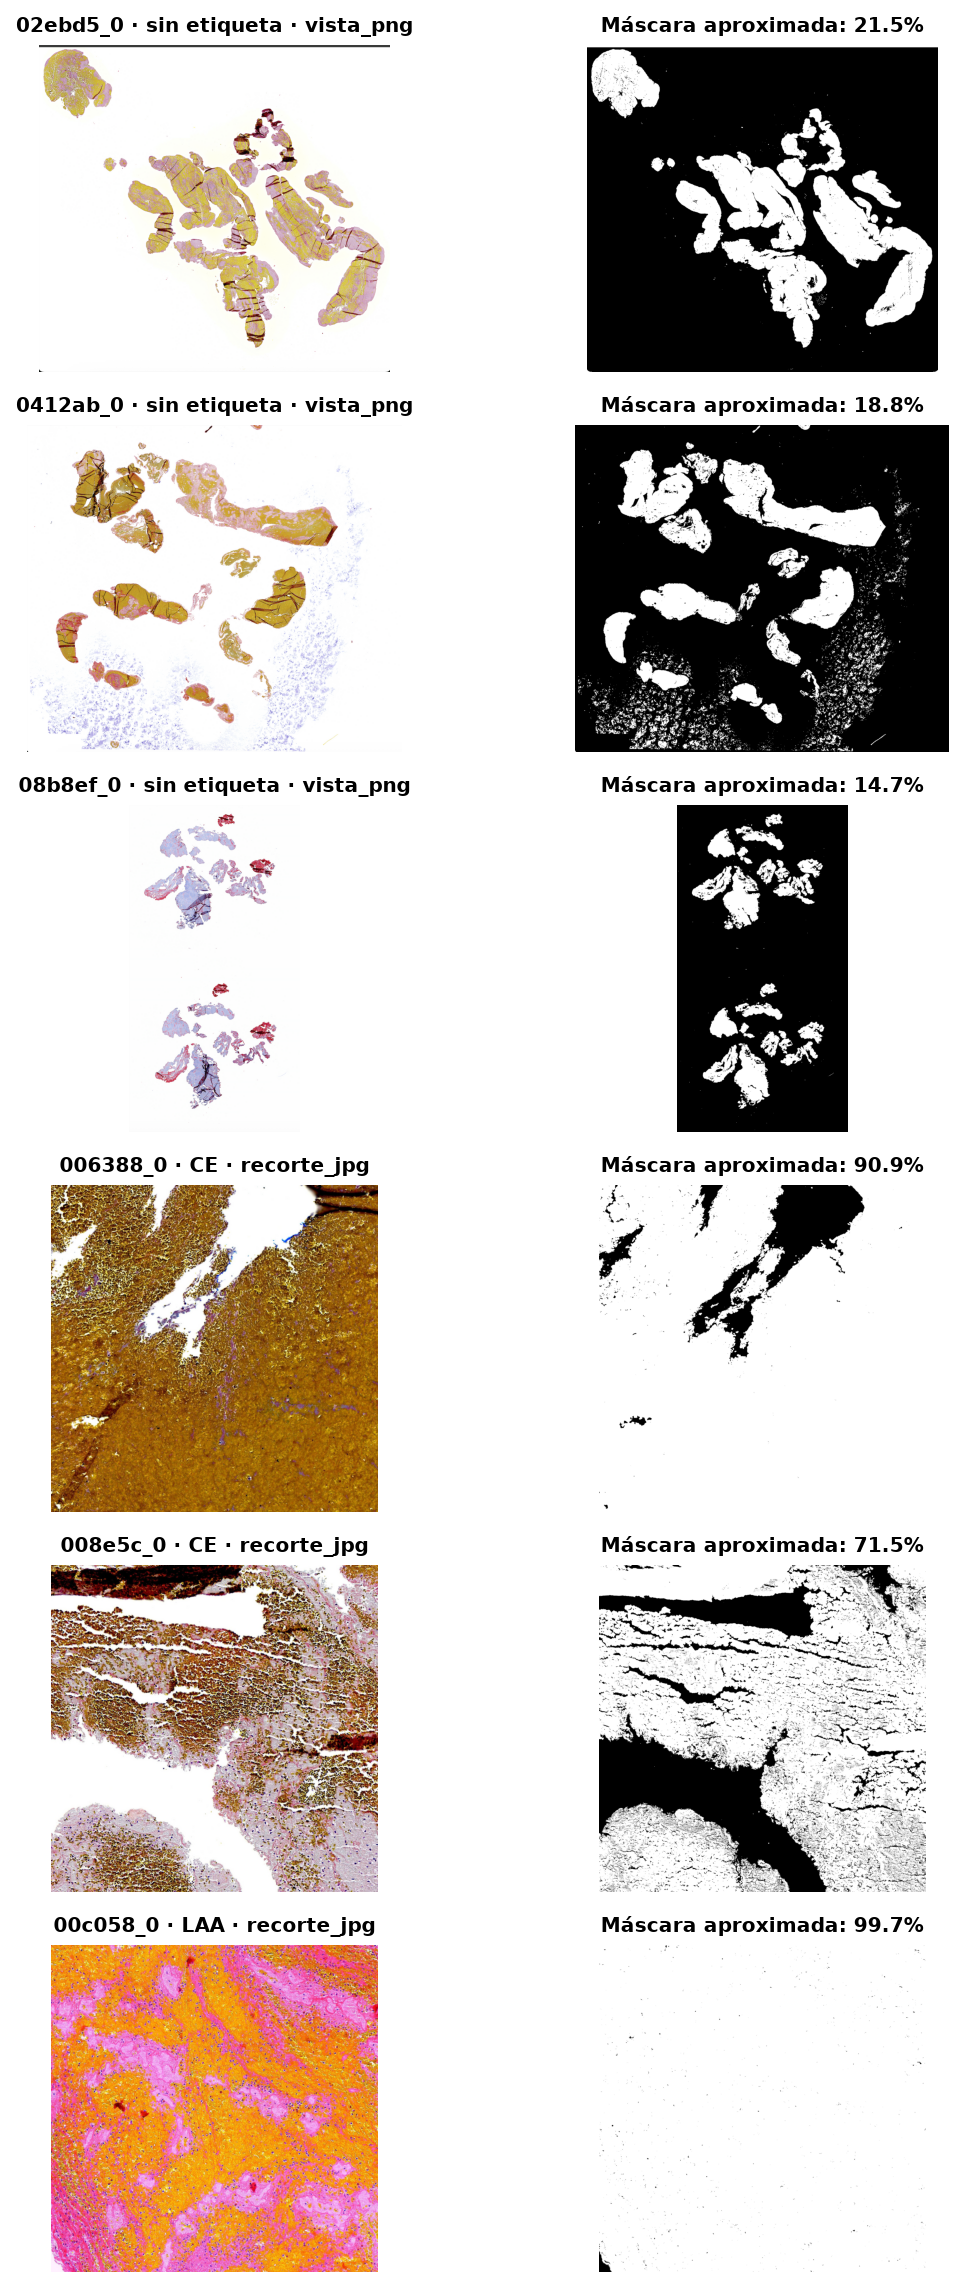

In [9]:
columnas = ["image_id", "preparacion", "label", "estado_etiqueta", "center_id",
            "ancho_px", "alto_px", "tamano_mb", "tejido_fraccion",
            "tiles_candidatos", "tiles_aceptados", "pixeles_borde_omitidos"]
display(imagenes[columnas])
display(tabla("control_tiles"))
print("Faltantes en el inventario (origen: falta de correspondencia en el CSV):")
display(imagenes[["label", "patient_id", "center_id"]].isna().sum().to_frame("nulos"))
figura("04_imagenes_y_mascaras", 760)

**Lectura del inventario:** `02ebd5_0`, `0412ab_0` y `08b8ef_0` no tienen coincidencia en `train.csv`. Se conservan sin etiqueta para el análisis técnico. Esa ausencia no equivale a las categorías clínicas `Unknown` u `Other` de otros archivos del reto.

Los recortes `006388_0` y `008e5c_0` corresponden a CE; `00c058_0`, a LAA. Los tres pertenecen al centro 11. Son apenas tres de los 754 identificadores del CSV. Las vistas PNG y los recortes JPG tienen preparaciones distintas; se presentan por imagen y se distinguen en los gráficos.

La máscara puede incluir tinta, ruido, fondo no blanco o artefactos, y omitir tejido muy claro. La selección de regiones con tejido en los JPG del proyecto de referencia también condiciona su cobertura. No interpretar diferencias de cobertura o resolución como diferencias propias de CE/LAA.

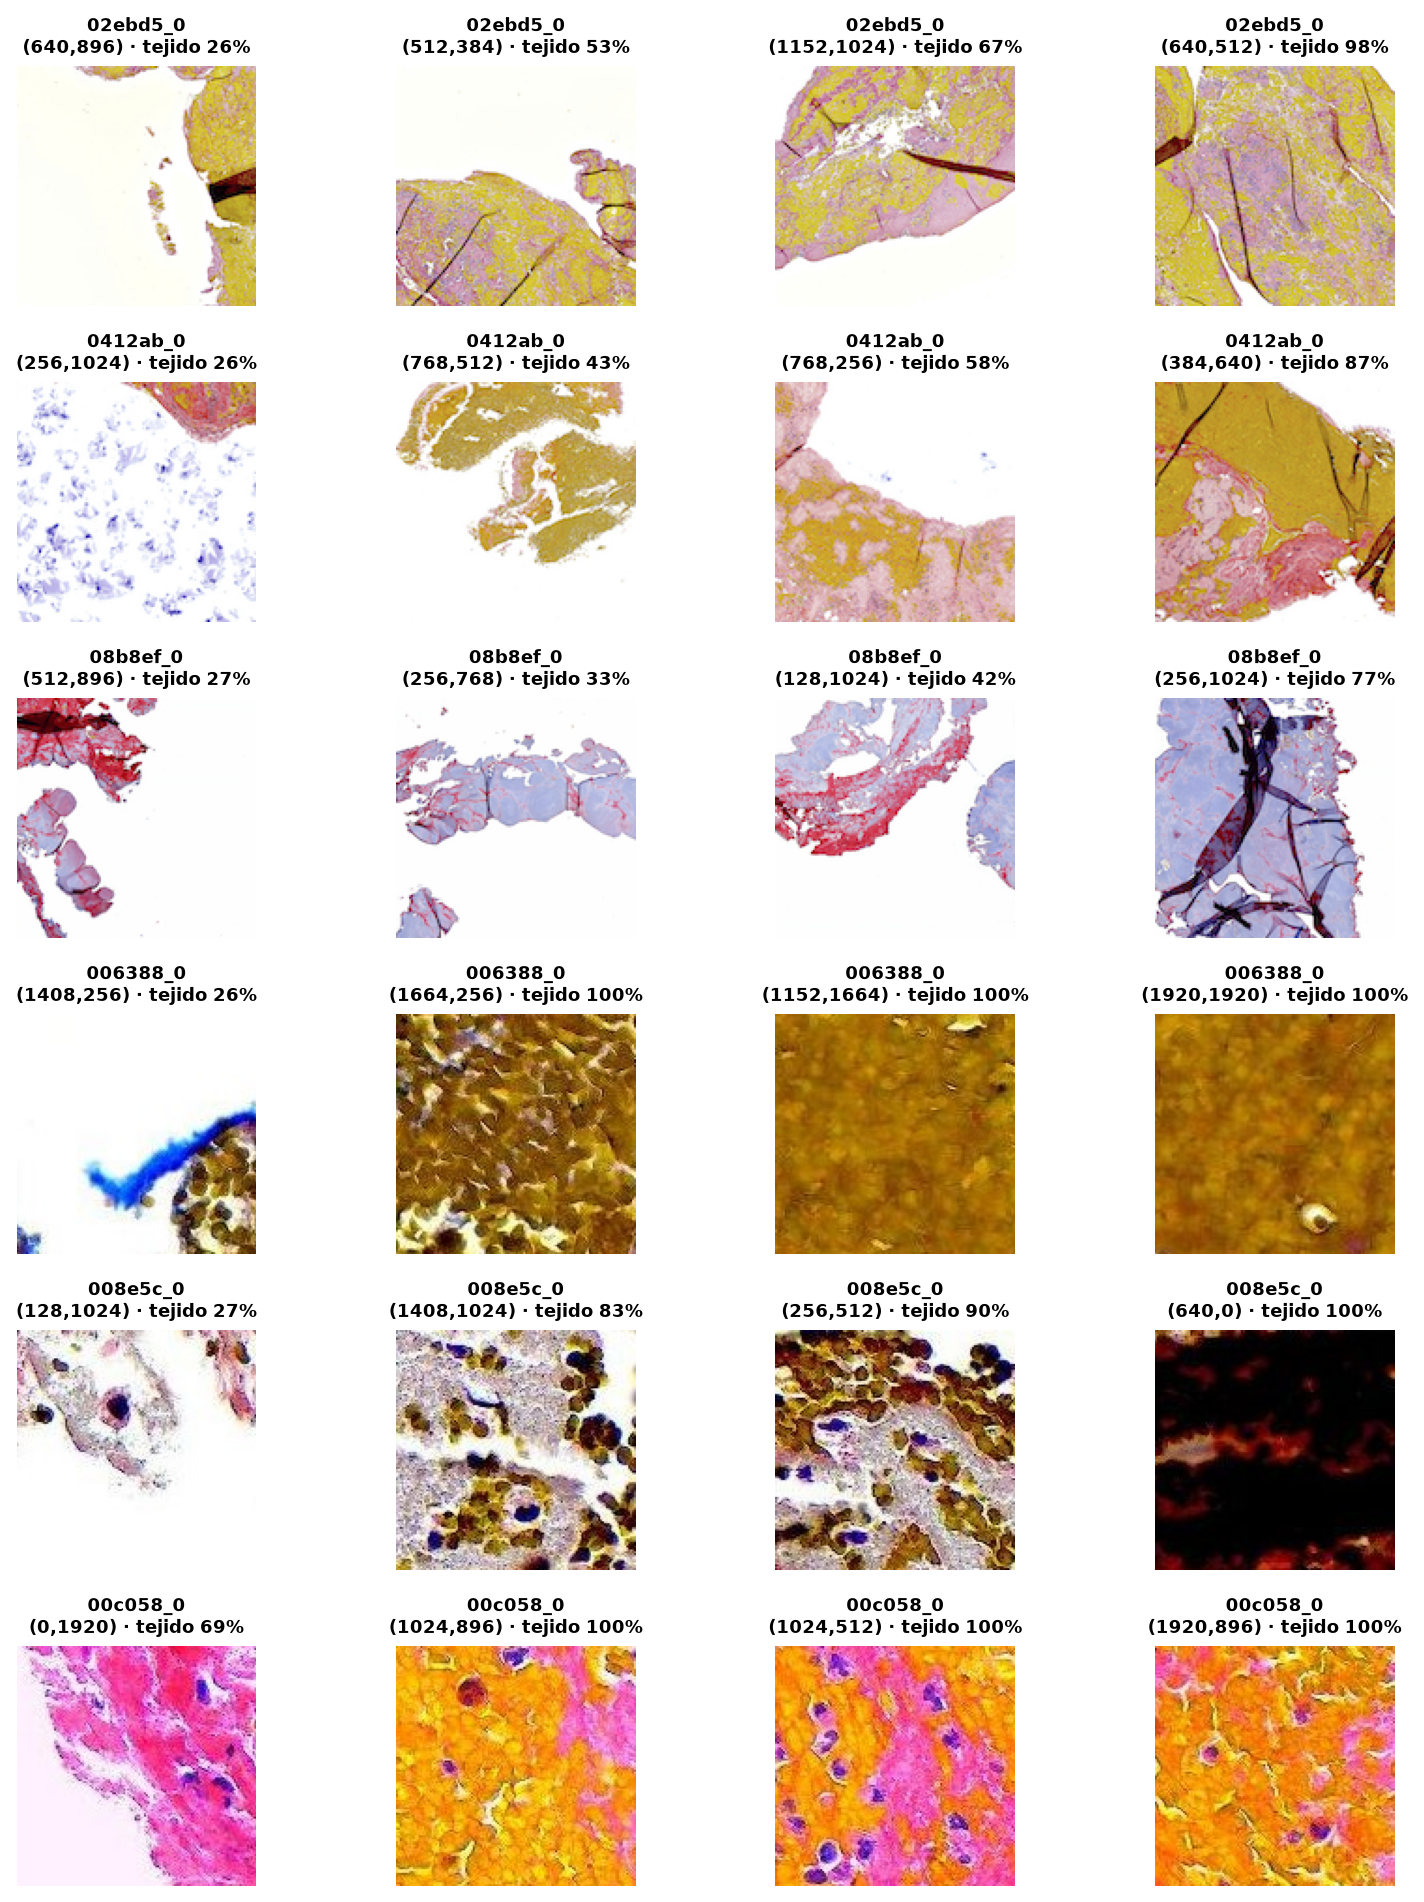

,image_id,x,y,lado,tejido_fraccion,nitidez_laplaciano,gris_media,gris_std,entropia_gris,r_tejido,g_tejido,b_tejido
0,02ebd5_0,0,0,128,0.674072,4023.477919,190.892583,54.403217,5.664435,183.154564,159.027979,107.684987
1,02ebd5_0,128,0,128,0.584839,3454.308153,196.432403,57.379561,5.326462,178.754331,150.571593,120.391254
11,02ebd5_0,0,128,128,0.605103,4237.146368,202.891187,44.893532,5.548522,192.725338,168.005850,118.751866
12,02ebd5_0,128,128,128,0.890198,5547.666527,179.342885,34.437826,6.563547,195.721906,169.004731,111.933082
29,02ebd5_0,896,256,128,0.436707,3902.697970,199.852676,73.195976,5.126391,167.177079,112.893501,120.021104
37,02ebd5_0,512,384,128,0.530884,2609.991576,210.333666,44.613438,5.038603,199.551621,168.093930,119.765463
39,02ebd5_0,768,384,128,0.582458,4085.178857,193.964124,64.145413,5.970469,181.787907,142.716441,116.331447
40,02ebd5_0,896,384,128,0.469543,3541.706936,198.029519,72.557827,5.408757,166.280125,124.012089,114.672689


In [10]:
figura("05_mosaico_tiles", 950)
display(aceptados[["image_id", "x", "y", "lado", *METRICAS]].head(8))

El mosaico muestra, para cada imagen, hasta cuatro tiles distribuidos a lo largo de su cobertura de tejido ordenada. Es una selección para inspección visual, no un muestreo aleatorio representativo de pacientes. Las coordenadas permiten localizar cada recorte en el archivo local.

## 11. Estadísticas numéricas y distribuciones visuales

| Métrica | Definición e interpretación |
|---|---|
| `tejido_fraccion` | Proporción de píxeles marcados; entre 0 y 1 |
| `nitidez_laplaciano` | Varianza del Laplaciano de luminancia; sensible a bordes, escala y ruido |
| `gris_media`, `gris_std` | Media y desviación poblacional de luminancia, incluyendo fondo |
| `entropia_gris` | Entropía Shannon del histograma de gris de 256 niveles, en bits (0–8) |
| `r_tejido`, `g_tejido`, `b_tejido` | Media de cada canal solo sobre la máscara (0–255); faltante sin tejido |
| `ancho_px`, `alto_px`, `tamano_mb` | Dimensiones y tamaño de los archivos derivados |

El resumen global describe únicamente los seis archivos presentes. Las comparaciones principales se hacen por imagen; los histogramas distinguen preparación. La desviación entre tiles no es incertidumbre entre pacientes.

,Unnamed: 0,count,mean,std,min,25%,50%,75%,max
0,tejido_fraccion,6.0,0.528543,0.389781,0.146677,0.194574,0.465074,0.860809,0.997304
1,nitidez_laplaciano,6.0,4040.105368,4516.865763,937.682013,1078.082265,2358.567299,4546.494574,12658.758008
2,gris_media,6.0,192.219273,52.501544,118.720141,159.023747,199.168111,237.101011,240.871674
3,gris_std,6.0,47.452547,19.497033,30.226958,36.364085,39.484519,53.020662,82.662638
4,entropia_gris,6.0,4.908986,2.391610,2.183993,3.008770,4.988608,7.048321,7.208990
5,r_tejido,6.0,183.808028,31.803416,147.404270,159.440122,186.882235,194.788795,233.962361
6,g_tejido,6.0,137.561988,25.630432,99.024340,121.792768,142.543595,158.758862,162.220621
7,b_tejido,6.0,109.251704,51.178881,27.226671,96.916083,112.146923,123.355685,185.058629
8,ancho_px,6.0,1622.333333,544.873441,684.000000,1433.500000,1770.000000,2048.000000,2048.000000
9,alto_px,6.0,1678.000000,405.340351,1302.000000,1308.500000,1682.000000,2048.000000,2048.000000


tejido_fraccion                      nitidez_laplaciano             \
                   count   mean    std median              count       mean   
image_id                                                                      
006388_0             247  0.942  0.157  1.000                247   3614.125   
008e5c_0             221  0.821  0.157  0.871                221  14386.361   
00c058_0             256  0.997  0.019  0.999                256   4832.200   
02ebd5_0              36  0.602  0.176  0.594                 36   2745.611   
0412ab_0              31  0.525  0.169  0.491                 31   2331.373   
08b8ef_0              15  0.417  0.135  0.386                 15   3063.246   

                              gris_media           ... r_tejido           \
               std     median      count     mean  ...      std   median   
image_id                                           ...                     
006388_0  3280.161   2457.158        247  113.839  ...   11.196  147.784   
008e5c_0  5460.717  16019.943        221  148.687  ...   31.156  156.673   
00c058_0  1861.367   4530.983        256  157.846  ...    5.446  235.235   
02ebd5_0  1054.133   2697.661         36  203.515  ...   10.130  200.066   
0412ab_0  1578.995   1887.136         31  203.913  ...   15.089  197.017   
08b8ef_0  1346.376   2895.672         15  218.110  ...   14.106  183.160   

         g_tejido                           b_tejido                            
            count     mean     std   median    count     mean     std   median  
image_id                                                                        
006388_0      247  100.049  11.404   99.158      247   30.887  27.504   20.535  
008e5c_0      221  119.914  35.134  121.627      221  104.492  44.408   97.249  
00c058_0      256  130.822  15.894  132.407      256   95.238  51.640   85.405  
02ebd5_0       36  164.923  13.876  168.514       36  124.823  16.135  120.522  
0412ab_0       31  154.551  19.310  150.213       31  105.423  41.869   96.259  
08b8ef_0       15  159.018  20.997  161.254       15  190.852  21.746  195.345  

[6 rows x 32 columns]

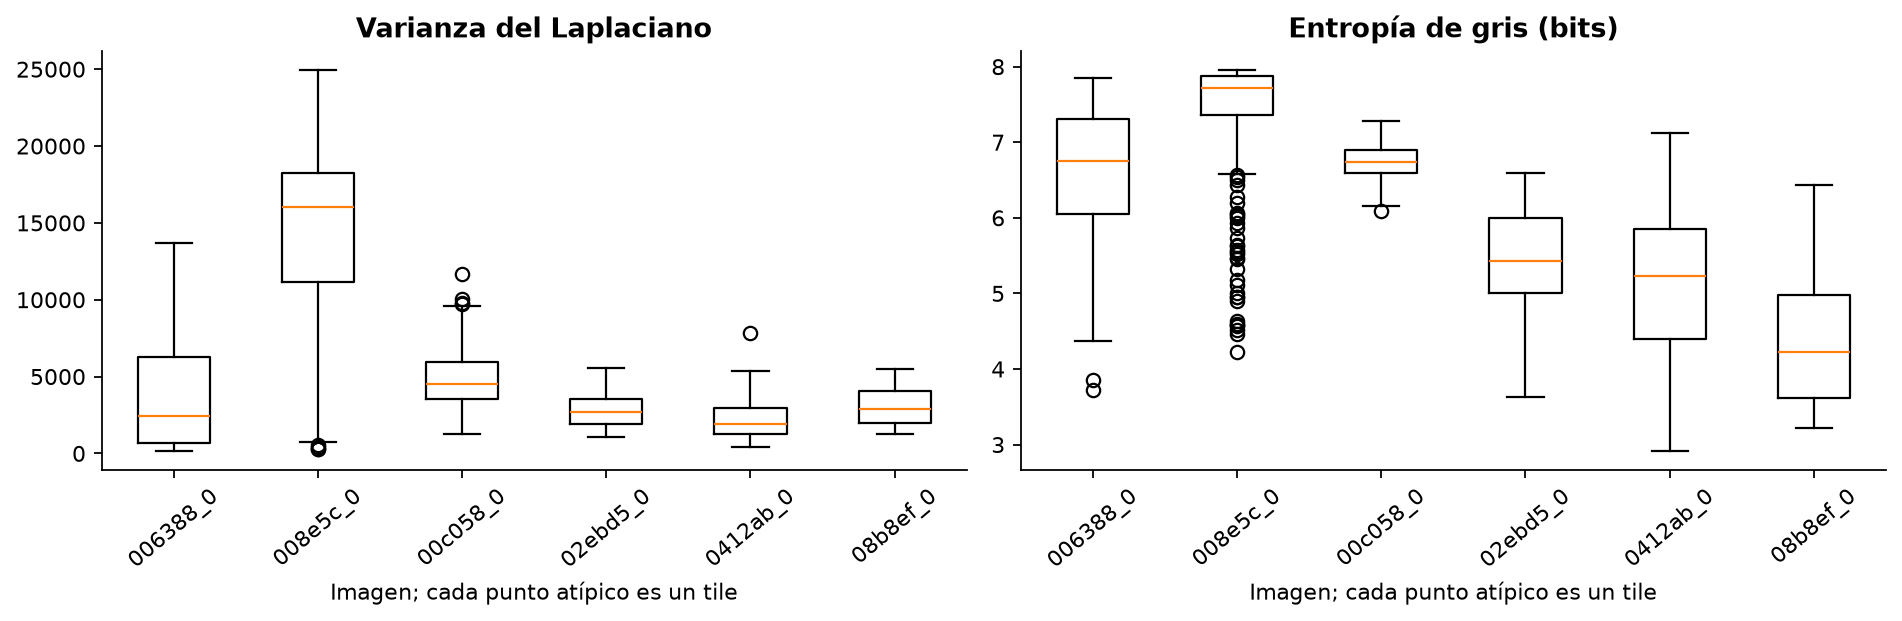

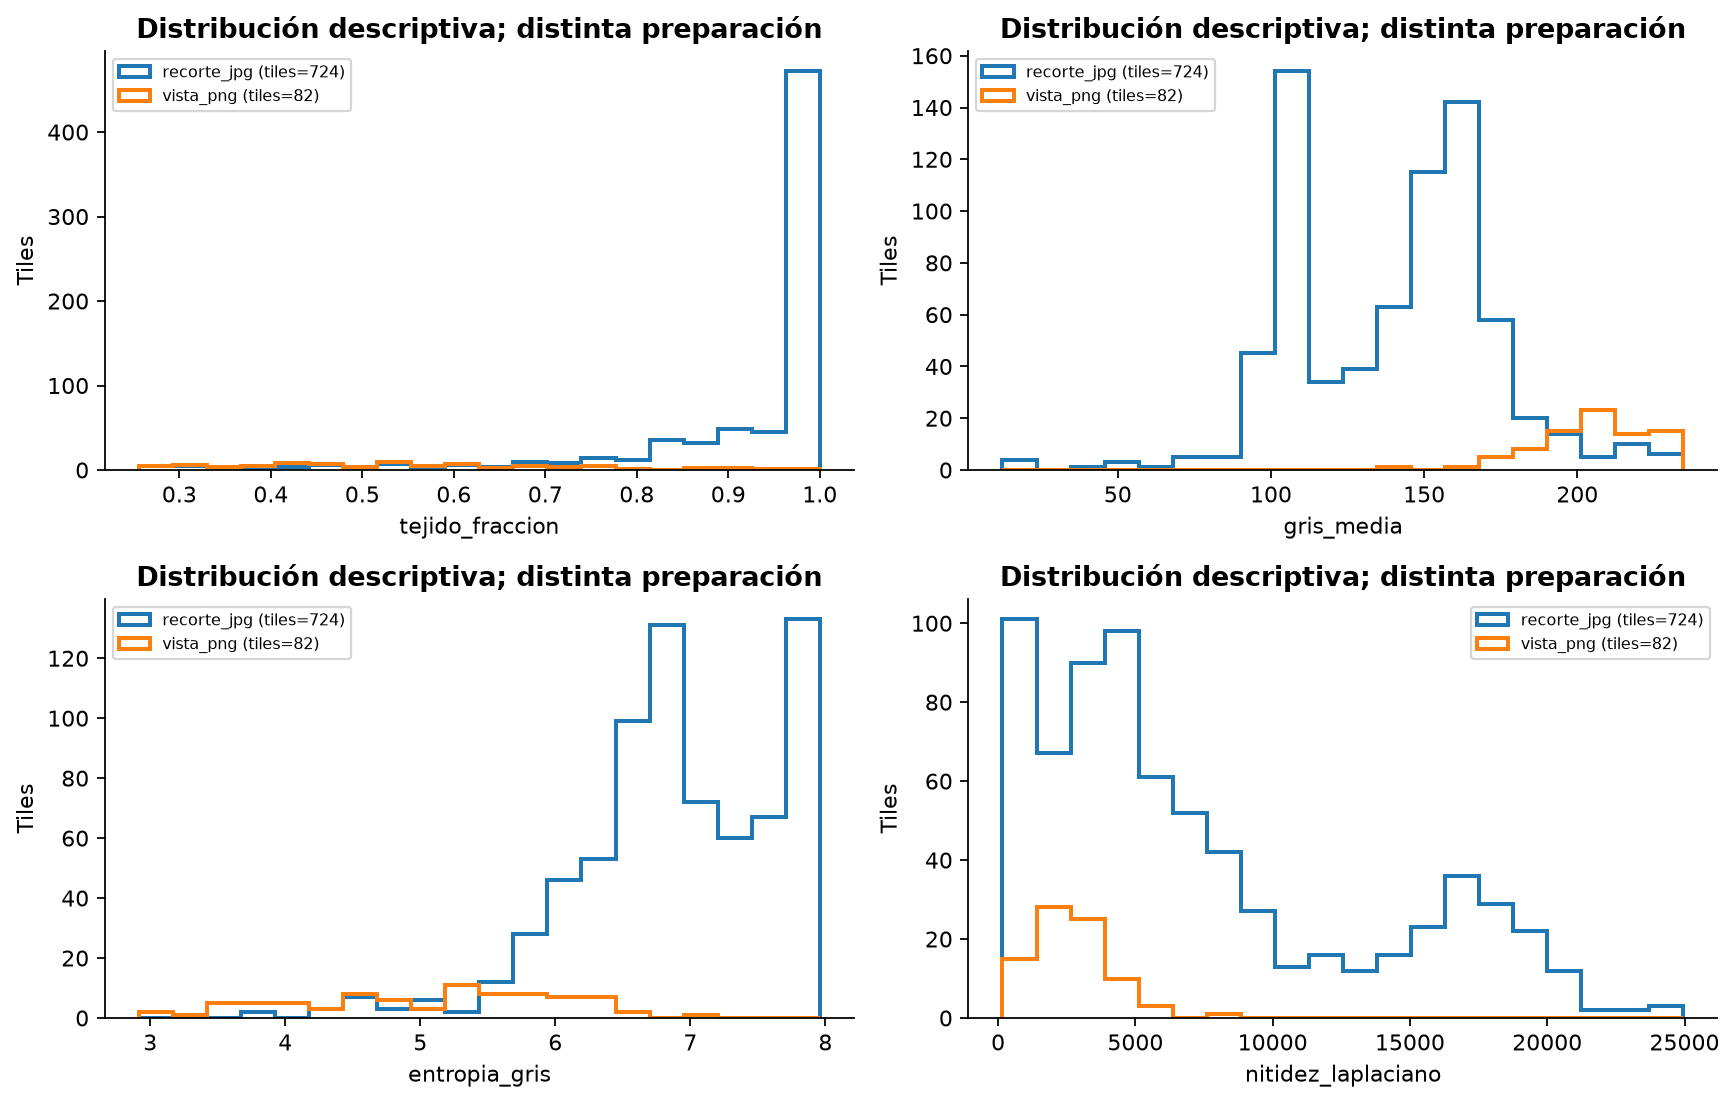

In [11]:
display(tabla("resumen_imagenes"))
display(aceptados.groupby("image_id")[METRICAS].agg(["count", "mean", "std", "median"]).round(3))
figura("06_cajas_por_imagen")
figura("07_histogramas_tiles")

Entre los tiles aceptados, la mediana de entropía más alta aparece en **008e5c_0** (7.715 bits) y la más baja en **08b8ef_0** (4.221 bits). **008e5c_0** tiene la mayor mediana del Laplaciano. Estos resultados describen variabilidad visual local. La mayor respuesta del Laplaciano puede deberse a detalle, ruido o bordes; la entropía no es una medida de severidad del ACV. Los histogramas se calculan después del filtrado, que recorta por construcción la distribución de cobertura.

## 12. Valores atípicos y decisiones de calidad

Se aplica la regla de Tukey: menor que `Q1 − 1.5 × IQR` o mayor que `Q3 + 1.5 × IQR`. En pacientes se usa sobre el conteo de imágenes; en tiles se usa dentro de cada imagen sobre cobertura, nitidez y entropía.

**Señalar no equivale a borrar.** Las múltiples imágenes de un paciente son válidas. En los tiles, transiciones bruscas, compresión, fondo o textura real pueden generar extremos. Se exportan coordenadas para revisión. No se usa un z-score global para mezclar imágenes de distintas preparaciones.

In [12]:
display(pacientes[pacientes.atipico_iqr].head(10))
flags = [col for col in aceptados if col.startswith("atipico_")]
display(aceptados.groupby("image_id")[flags].sum())
atipicos = aceptados[aceptados[flags].any(axis=1)]
display(atipicos.sort_values("nitidez_laplaciano", ascending=False)
        [["image_id", "x", "y", "tejido_fraccion", "nitidez_laplaciano", "entropia_gris", *flags]].head(10))
print("Pacientes señalados:", int(pacientes.atipico_iqr.sum()))
print("Tiles aceptados señalados en al menos una métrica:", len(atipicos))

,patient_id,label,center_id,n_imagenes,atipico_iqr
15,0468a8,CE,11,2,True
16,049194,CE,5,2,True
23,09644e,CE,10,5,True
30,0b7871,CE,4,2,True
43,0e696a,CE,5,2,True
44,0ed87f,CE,2,2,True
45,0ee750,LAA,6,2,True
50,112b6e,CE,11,2,True
63,19b036,CE,9,2,True
72,1db82d,LAA,4,2,True


,atipico_nitidez_laplaciano,atipico_entropia_gris,atipico_tejido_fraccion
image_id,,,
006388_0,0,2,52
008e5c_0,4,34,23
00c058_0,4,1,18
02ebd5_0,0,0,0
0412ab_0,1,0,0
08b8ef_0,0,0,1


,image_id,x,y,tejido_fraccion,nitidez_laplaciano,entropia_gris,atipico_nitidez_laplaciano,atipico_entropia_gris,atipico_tejido_fraccion
274,006388_0,512,0,0.940796,13668.197548,7.852876,False,False,True
538,008e5c_0,1536,0,0.550720,12738.350085,6.568171,False,True,True
740,008e5c_0,768,1664,0.448303,12531.345461,5.871354,False,True,True
290,006388_0,512,128,0.977722,12471.805726,7.849719,False,False,True
678,008e5c_0,1024,1152,0.541626,11838.632999,6.582148,False,False,True
975,00c058_0,128,1536,0.994385,11682.172867,7.239224,True,False,True
350,006388_0,0,640,0.950500,11588.353538,7.837342,False,False,True
675,008e5c_0,640,1152,0.461975,11527.106573,6.270284,False,True,True
1024,00c058_0,256,1920,0.989929,10072.192925,7.204650,True,False,True
656,008e5c_0,256,1024,0.481262,10009.437499,6.029137,False,True,True


Pacientes señalados: 89
Tiles aceptados señalados en al menos una métrica: 110


**Interpretación:** Q1 y Q3 del conteo de imágenes por paciente son ambos 1, así que IQR=0. La regla marca todo conteo mayor que 1; ello refleja una distribución discreta concentrada, no evidencia de registros incorrectos. Se conservan esas filas.

Los extremos de las métricas visuales también se conservan. Se distingue el filtro operativo de poco tejido/baja respuesta del Laplaciano de la detección estadística de extremos dentro de las regiones ya aceptadas. Las tablas permiten revisar ambas decisiones sin perder observaciones.

## 13. Relaciones, dispersión y correlaciones

El gráfico de dispersión explora cobertura frente a entropía. Se identifica cada imagen para no ocultar agrupaciones. Las matrices usan **Spearman dentro de cada imagen**: una relación por rangos adecuada para describir asociaciones monotónicas sin exigir distribuciones normales. No se calculan p-valores ni se toma cada tile como paciente independiente.

No se correlacionan numéricamente `center_id` ni identificadores. Los canales RGB pueden correlacionarse por iluminación, tinción o fondo; tal relación no demuestra una causa médica.

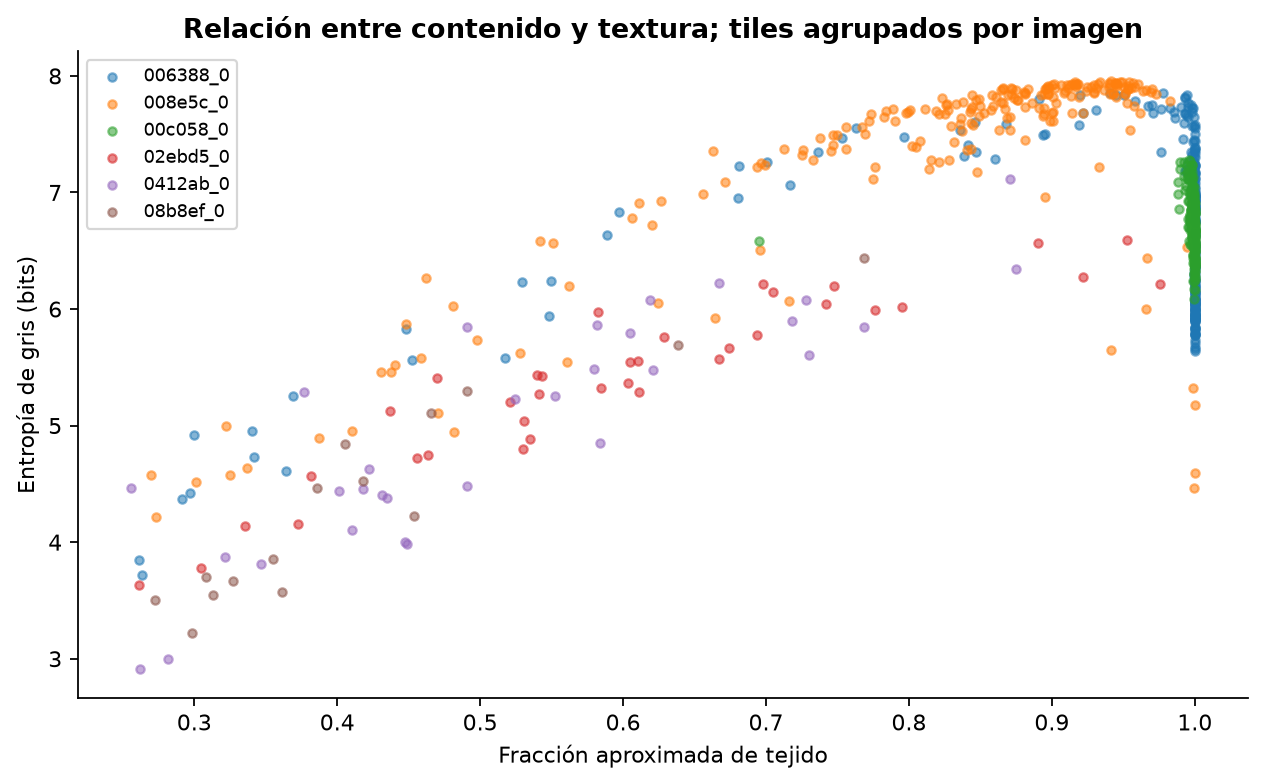

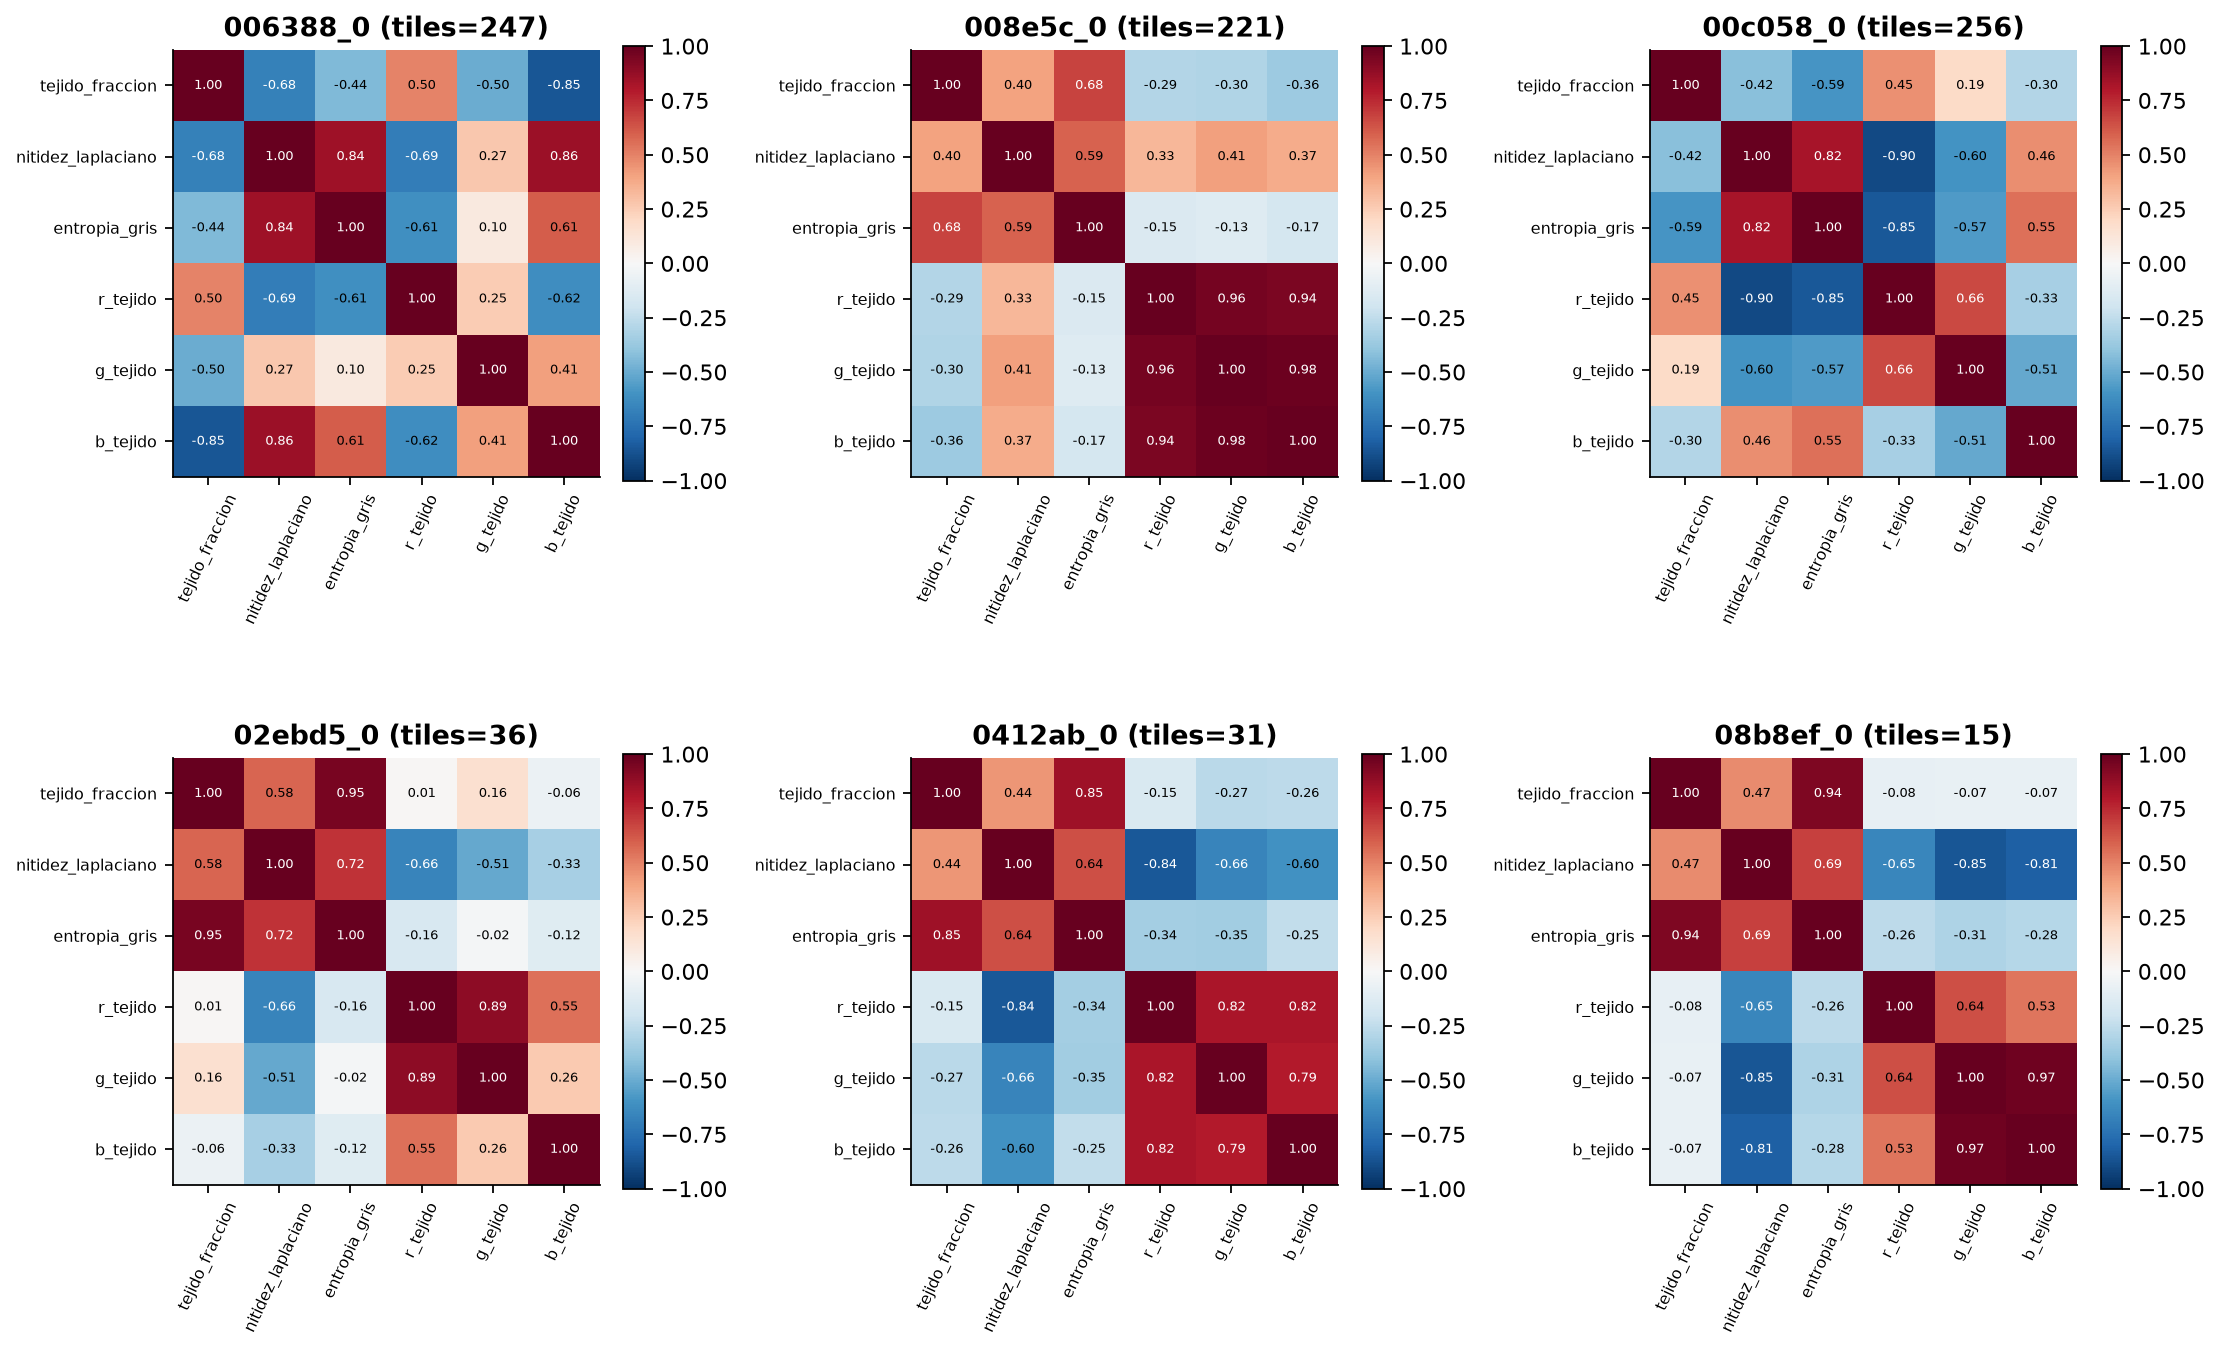

,image_id,n_tiles,rho_tejido_entropia,rho_r_g
0,006388_0,247,-0.444,0.252
1,008e5c_0,221,0.676,0.960
2,00c058_0,256,-0.589,0.663
3,02ebd5_0,36,0.948,0.895
4,0412ab_0,31,0.847,0.818
5,08b8ef_0,15,0.936,0.643


In [13]:
figura("08_dispersion_tejido_entropia")
figura("09_correlaciones_por_imagen", 1100)
relaciones=[]
for iid, grupo in aceptados.groupby("image_id"):
    matriz=grupo[METRICAS].corr(method="spearman")
    relaciones.append({"image_id":iid, "n_tiles":len(grupo),
        "rho_tejido_entropia":matriz.loc["tejido_fraccion","entropia_gris"],
        "rho_r_g":matriz.loc["r_tejido","g_tejido"]})
display(pd.DataFrame(relaciones).round(3))

La relación cobertura–entropía de mayor magnitud absoluta aparece en **02ebd5_0**, con Spearman **0.948** dentro de esa imagen. La tabla permite observar si la dirección se mantiene entre imágenes. La cobertura cambia la mezcla de tejido y fondo, lo que puede modificar el histograma de gris. Se trata de una explicación técnica plausible, no una relación causal demostrada ni evidencia de que las clases sean separables.

## 14. Sensibilidad del preprocesamiento y comparación ilustrativa CE/LAA

Se cambia el mínimo de cobertura a 10 %, 25 % y 50 %, manteniendo la misma cuadrícula y el umbral del Laplaciano. Esto permite cuantificar cuánto depende la selección de una decisión del análisis. No se selecciona un umbral para maximizar diferencias entre clases.

La figura por clase usa un punto por recorte etiquetado: CE tiene dos pacientes y LAA uno. No se hacen pruebas de significancia ni se presentan intervalos de confianza basados en tiles.

,image_id,min_tejido,tiles_aceptados,tiles_candidatos
0,02ebd5_0,0.10,47,110
1,02ebd5_0,0.25,36,110
2,02ebd5_0,0.50,27,110
3,0412ab_0,0.10,56,110
4,0412ab_0,0.25,31,110
5,0412ab_0,0.50,15,110
6,08b8ef_0,0.10,22,50
7,08b8ef_0,0.25,15,50
8,08b8ef_0,0.50,2,50
9,006388_0,0.10,248,256


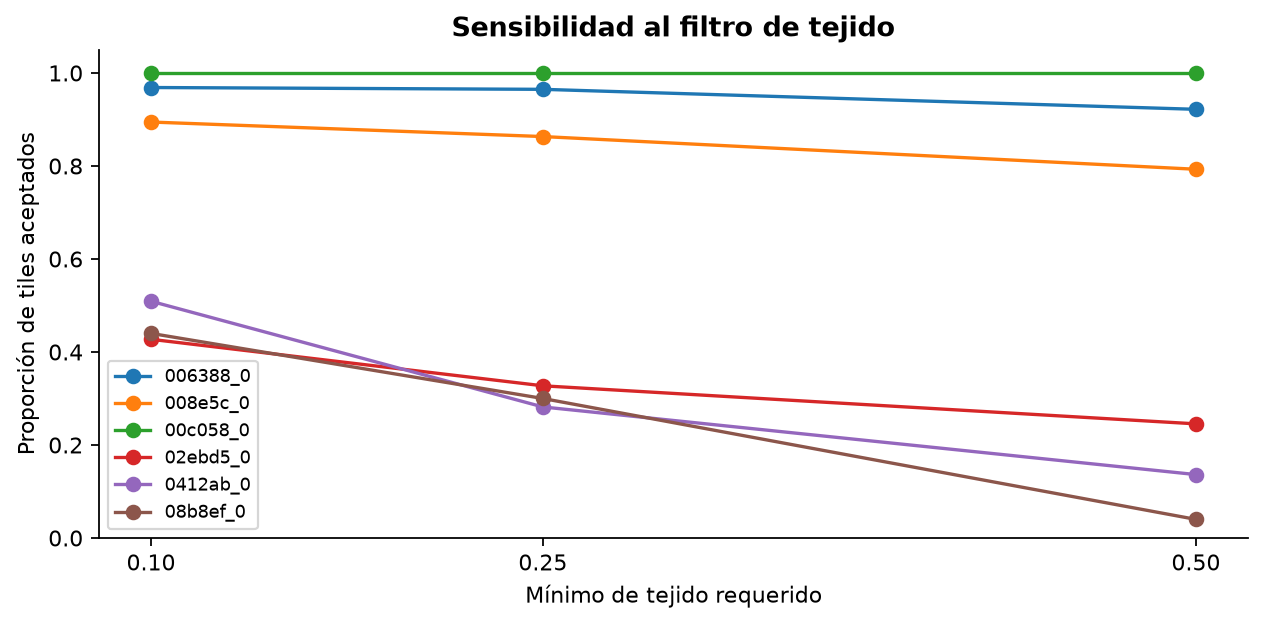

,image_id,patient_id,center_id,label,tejido_fraccion,nitidez_laplaciano,gris_media,gris_std,entropia_gris,r_tejido,g_tejido,b_tejido
3,006388_0,006388,11,CE,0.909489,3529.945313,118.720141,57.233744,7.092694,147.404270,99.024340,27.226671
4,008e5c_0,008e5c,11,CE,0.714768,12658.758008,162.557790,82.662638,7.208990,152.583650,118.770329,102.334301
5,00c058_0,00c058,11,LAA,0.997304,4885.344328,157.845733,30.226958,6.915202,233.962361,130.860085,95.110010


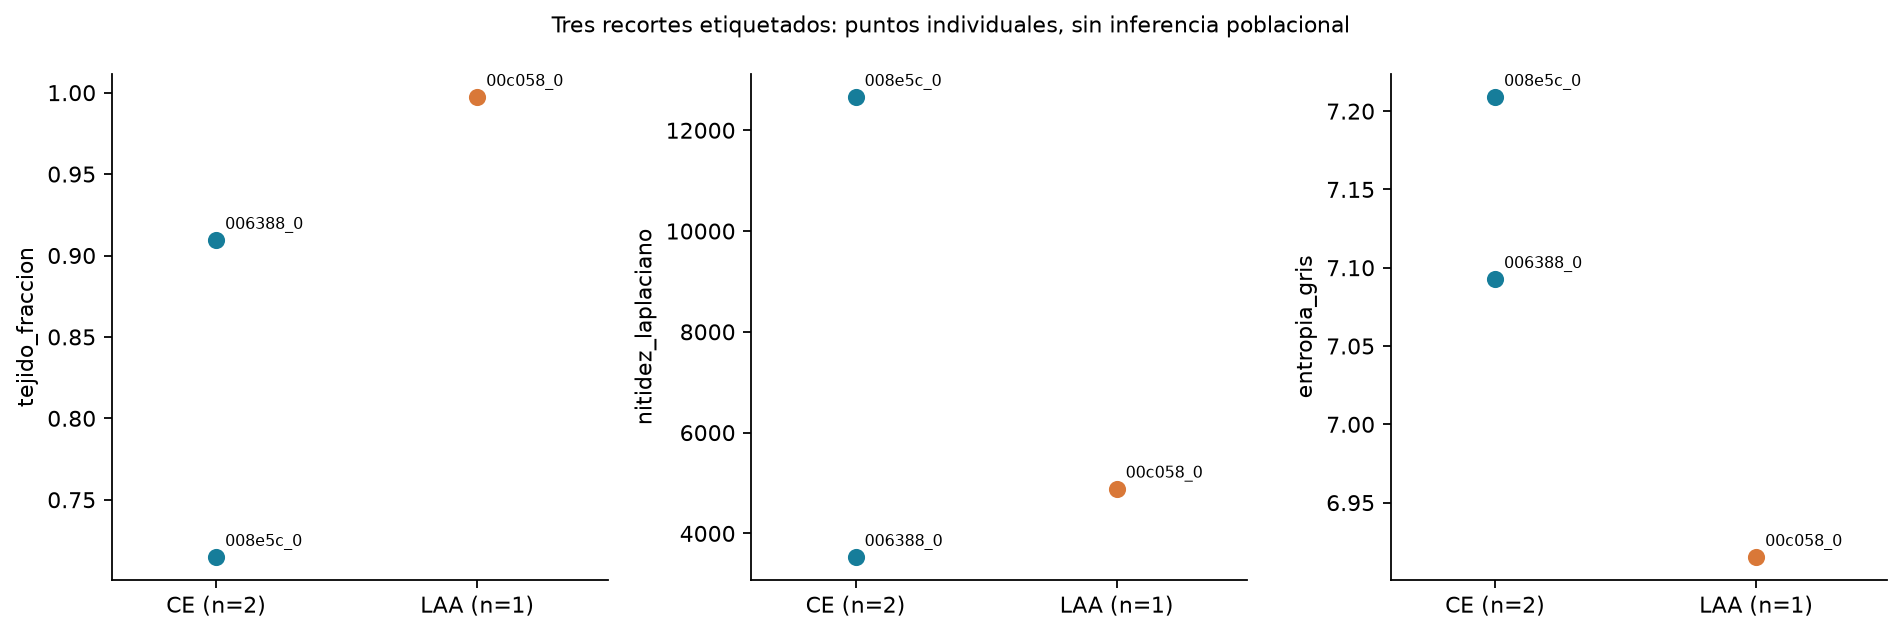

In [14]:
display(tabla("sensibilidad_filtro_tejido"))
figura("10_sensibilidad_filtro")
display(imagenes.loc[imagenes.label.notna(), ["image_id", "patient_id", "center_id", "label", *METRICAS]])
figura("11_tres_recortes_etiquetados")

Con mínimos de 10 %, 25 % y 50 % se aceptan **858**, **806** y **739** tiles, respectivamente. Elevar el requisito no puede añadir tiles, porque las demás condiciones permanecen fijas. La sensibilidad documenta la selección técnica; no determina el mejor umbral clínico. Los tres recortes etiquetados permiten ilustrar el procedimiento, pero no concluir que sus diferencias caractericen a toda la clase CE o LAA.

## 15. Hallazgos, conclusiones y siguientes pasos

Los siguientes hallazgos corresponden a los datos analizados. Las interpretaciones están escritas en celdas Markdown y deben revisarse si se cambian los datos o los parámetros.

### Metadatos y unidad de análisis

- Se analizaron **754 registros, 5 variables, 632 pacientes y 11 centros**.
- Por imagen: CE **547 (72.55%)** y LAA **207 (27.45%)**. Por paciente: CE **457 (72.31%)** y LAA **175 (27.69%)**. Existe desbalance descriptivo; la frecuencia de esta muestra no es prevalencia poblacional.
- Hay **89 pacientes con más de una imagen**, hasta 5 imágenes. Las observaciones del mismo paciente no son independientes. Una eventual división para modelos debe agrupar por paciente.
- Se encontraron **0 nulos** después de normalizar y se eliminaron **0 duplicados exactos**. No se imputaron etiquetas ni identificadores. Los originales se conservan.
- Los códigos de centro e identificadores no son medidas clínicas continuas: no se interpretan promedios ni correlaciones numéricas de sus códigos.

### Relaciones entre variables

- La proporción CE por paciente va de **50.00% (centro 3)** a **87.50% (centro 8)**. La tabla de conteos permite valorar los distintos tamaños por centro. Es una asociación descriptiva compatible con diferencias de selección de casos; no demuestra que el centro cause la etiología.
- La mediana de imágenes por paciente es **1**. Q1 y Q3 son 1 y 1; IQR=0 hace que la regla de Tukey marque las repeticiones como atípicas. Se conservan porque son observaciones válidas, no errores demostrados.

### Imágenes disponibles y calidad

- Se analizaron **6 archivos derivados locales**, no las WSI originales. Solo **3** coinciden con `train.csv` (**0.40%** de los identificadores del CSV); esos recortes corresponden a **3 pacientes**, todos del centro **11**.
- Los identificadores **02ebd5_0, 0412ab_0, 08b8ef_0** no aparecen en el CSV. Se mantienen sin etiqueta; no se les asigna CE, LAA, `Unknown` ni `Other` por apariencia o por similitud del nombre.
- Las vistas PNG y los recortes JPG tienen preparaciones y escalas distintas. No se considera que sean una muestra aleatoria ni comparable de toda la colección.
- La cuadrícula de 128 × 128 píxeles generó **1038 tiles candidatos**, de los que **806** superaron los filtros y **232** quedaron rechazados. No se insertan recortes de respaldo que incumplan los filtros. Las coordenadas corresponden a los archivos locales.
- La regla IQR dentro de cada imagen señala **110 tiles aceptados** en al menos una métrica de calidad. Permanecen disponibles para revisión; no se borran por ser extremos. Los bordes, la compresión y las transiciones tejido/fondo pueden producir valores altos del Laplaciano.

### Alcance de las conclusiones

Se han caracterizado el desbalance, las repeticiones por paciente, la composición por centro y la variabilidad técnica de las imágenes disponibles. Las métricas de color, entropía y nitidez describen píxeles; no miden directamente eritrocitos, plaquetas o fibrina. Las correlaciones se calculan entre tiles dentro de cada imagen y no prueban relación causal ni poder diagnóstico.

**Dos pacientes CE y uno LAA, todos del mismo centro, no permiten establecer diferencias generales entre etiologías ni validar un clasificador.** No se entrenó un modelo ni se informan métricas predictivas. Más tiles no aumentan el número de pacientes.

Los siguientes pasos son ampliar la muestra con imágenes de identificación verificable y varios centros, documentar escala y tinción, revisar manualmente las máscaras y evaluar el efecto de los filtros. Si después se pide modelado, separar pacientes y revisar sesgo por centro. Estos resultados delimitan el alcance del análisis exploratorio.


## 16. Fuentes y entregables

Las referencias de contexto se enlazan en las secciones correspondientes. Los resultados proceden de los archivos locales; su origen y SHA-256 se registran en `datos/procedencia.json`.

**Referencias**

1. NINDS. [Stroke Overview](https://www.ninds.nih.gov/health-information/stroke/stroke-overview).
2. NINDS. [Signs and Symptoms](https://www.ninds.nih.gov/health-information/stroke/signs-and-symptoms).
3. NINDS. [Assess and Treat](https://www.ninds.nih.gov/health-information/stroke/assess-and-treat).
4. Mayo Clinic / Kaggle. [STRIP AI: Dataset Description](https://www.kaggle.com/competitions/mayo-clinic-strip-ai/data).
5. Fitzgerald et al. (2019). [Platelet-Rich Emboli in Cerebral Large Vessel Occlusion Are Associated with a Large Artery Atherosclerosis Source](https://pmc.ncbi.nlm.nih.gov/articles/PMC6910081/).
6. Roldán, D., Fuentes, A., Paz, G. y Marchena, J. (2025). *P2-DS*, Grupo 7. Proyecto de referencia utilizado como fuente inmediata de los archivos de datos.

**Entregables**

- [Informe final](<Proyecto 2 — Data Science.pdf>).
- [Presentación PowerPoint](presentacion/Clasificacion_Coagulos_ACV.pptx).
- [Presentación PDF](presentacion/Clasificacion_Coagulos_ACV.pdf).
- `resultados/tablas/`: estadísticas, auditoría, cruces y coordenadas de tiles.
- `resultados/figuras/`: gráficos del análisis.
- `resultados/configuracion.json`: parámetros y versiones de cálculo.


In [15]:
figuras = sorted((RAIZ / "resultados/figuras").glob("*.png"))
tablas = sorted((RAIZ / "resultados/tablas").glob("*.csv"))
print(f"Artefactos exportados: {len(figuras)} figuras y {len(tablas)} tablas.")
print("Figuras:")
for p in figuras:
    print(" -", p.name)

Artefactos exportados: 11 figuras y 30 tablas.
Figuras:
 - 01_balance_clases.png
 - 02_centro_clase.png
 - 03_imagenes_por_paciente.png
 - 04_imagenes_y_mascaras.png
 - 05_mosaico_tiles.png
 - 06_cajas_por_imagen.png
 - 07_histogramas_tiles.png
 - 08_dispersion_tejido_entropia.png
 - 09_correlaciones_por_imagen.png
 - 10_sensibilidad_filtro.png
 - 11_tres_recortes_etiquetados.png
